In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix

# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)



Path to dataset files: /home/samuele/.cache/kagglehub/datasets/shauryasrivastava01/liver-patient-dataset/versions/1


In [3]:
path = "Datasets/liver_patient_dataset.csv"
df = pd.read_csv(path)

In [4]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [5]:
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


### Distribuzione della classe Selector (il target)

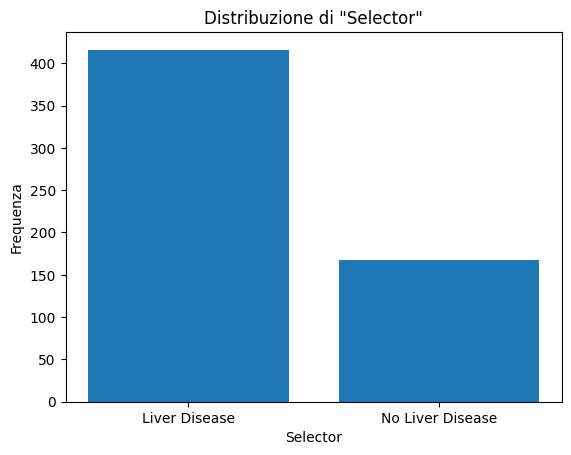

In [6]:
conteggi = df["Selector"].value_counts()

plt.bar(conteggi.index, conteggi.values)
plt.xlabel("Selector")
plt.ylabel("Frequenza")
plt.title('Distribuzione di "Selector"')
plt.show()

### Creazione trainining e testing set

In [7]:
feature_names = set(df.columns) - set(["Selector"])

target_name = "Selector"

categorical_features = set(["Gender"])
continuos_features = feature_names - set(["Gender"])

print(categorical_features)
print(continuos_features)
feature_names = list(feature_names)

{'Gender'}
{'Sgot', 'Age', 'DB', 'TB', 'Alkphos', 'ALB', 'TP', 'Sgpt', 'A/G Ratio'}


In [8]:
df_encoded = df.copy()

df_encoded["Gender"] = df_encoded["Gender"].astype("category").cat.codes
# Mapping esplicito: la classe positiva 1 indica la presenza di malattia epatica.
selector_mapping = {"Liver Disease": 1, "No Liver Disease": 0}
df_encoded["Selector"] = df_encoded["Selector"].map(selector_mapping)

if df_encoded["Selector"].isna().any():
    raise ValueError("Valori inattesi nella colonna Selector")

df_encoded["Selector"] = df_encoded["Selector"].astype("int8")

In [9]:
df_encoded

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [10]:
df_encoded["Selector"].dtype

dtype('int8')

In [11]:
df_encoded["Gender"].dtype

dtype('int8')

### addestriamo Il decisione Tree

In [12]:
y = df_encoded["Selector"]
#X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [13]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [14]:
X_train.head()

,Sgot,Age,DB,Gender,TB,A/G Ratio,Alkphos,TP,Sgpt,ALB
439,18,42,0.2,0,0.8,1.0,168,6.2,25,3.1
240,30,48,0.2,1,0.7,1.0,165,8.0,32,4.0
403,22,65,0.2,1,0.7,1.3,199,6.3,19,3.6
460,51,22,1.0,0,2.2,0.8,215,5.5,159,2.5
533,623,46,0.4,0,1.4,0.3,298,3.6,509,1.0


In [15]:
y_train.head()

439    1
240    0
403    0
460    1
533    1
Name: Selector, dtype: int8

In [16]:

model = DecisionTreeClassifier(random_state=42)
model = model.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(model, filled=True, ax=ax)
plt.plot()

[]

In [17]:
# [
#     true 0, false 1
#     false 0, true 1
#  ]

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[17 33]
 [28 97]]

Accuracy: 0.6514285714285715


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.34      0.38      0.36        45
           1       0.78      0.75      0.76       130

    accuracy                           0.65       175
   macro avg       0.56      0.56      0.56       175
weighted avg       0.66      0.65      0.66       175



### Miglioriamo l'albero

In [19]:
prunedModel = DecisionTreeClassifier(random_state=42,max_depth=5, min_samples_split=2)
prunedModel = prunedModel.fit(X_train, y_train)

# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(prunedModel, filled=True, ax=ax)
plt.plot()

[]

In [20]:
y_pred = prunedModel.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[ 10  40]
 [ 18 107]]

Accuracy: 0.6685714285714286


In [21]:
#precision: Tra tutti quelli che il modello ha predetto come positivi, quanti erano davvero positivi?
#recall: Tra tutti quelli che erano davvero positivi, quanti ne ha trovati il modello?

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.20      0.36      0.26        28
           1       0.86      0.73      0.79       147

    accuracy                           0.67       175
   macro avg       0.53      0.54      0.52       175
weighted avg       0.75      0.67      0.70       175



### L'albero ha una bassa accuratezza, Usiamo il parametro di complessità

In [23]:
path = model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00212418 0.00222816 0.00229779 0.00234886 0.00240944
 0.00245098 0.00294118 0.00306991 0.00326797 0.00326797 0.00326797
 0.00367647 0.00367647 0.00367647 0.00367647 0.0038393  0.00392157
 0.00392157 0.00392157 0.00392157 0.00399419 0.00405493 0.00408497
 0.0043219  0.0043573  0.00441176 0.0046024  0.00465077 0.00472689
 0.00481118 0.00522876 0.00533769 0.0056096  0.00573133 0.00624629
 0.00640333 0.00671877 0.00692501 0.00820028 0.00844524 0.00952593
 0.0095872  0.00974278 0.01705843 0.03734733]


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

results = []
#andare oltre 8 lo manda comunque in overfitting

for depth in range(4, 8):
    for complexity in ccp_alphas:
        clf = DecisionTreeClassifier(
            max_depth=depth,
            ccp_alpha=complexity,
            class_weight="balanced",
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = clf.score(X_train, y_train)
        test_acc = clf.score(X_test, y_test)

        results.append({
            "max_depth": depth,
            "ccp_alpha": complexity,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc
        })

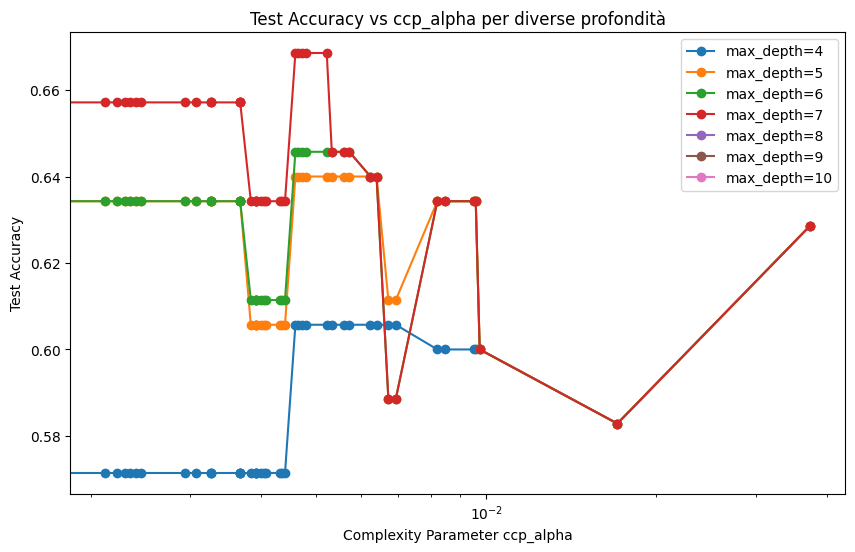

In [25]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    test_acc = [r["test_accuracy"] for r in depth_results]

    plt.plot(alphas, test_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [26]:
best_result = max(results, key=lambda x: x["test_accuracy"])

print("Miglior max_depth:", best_result["max_depth"])
print("Miglior ccp_alpha:", best_result["ccp_alpha"])
print("Train accuracy:", best_result["train_accuracy"])
print("Test accuracy:", best_result["test_accuracy"])

Miglior max_depth: 7
Miglior ccp_alpha: 0.004602396514161223
Train accuracy: 0.7769607843137255
Test accuracy: 0.6685714285714286


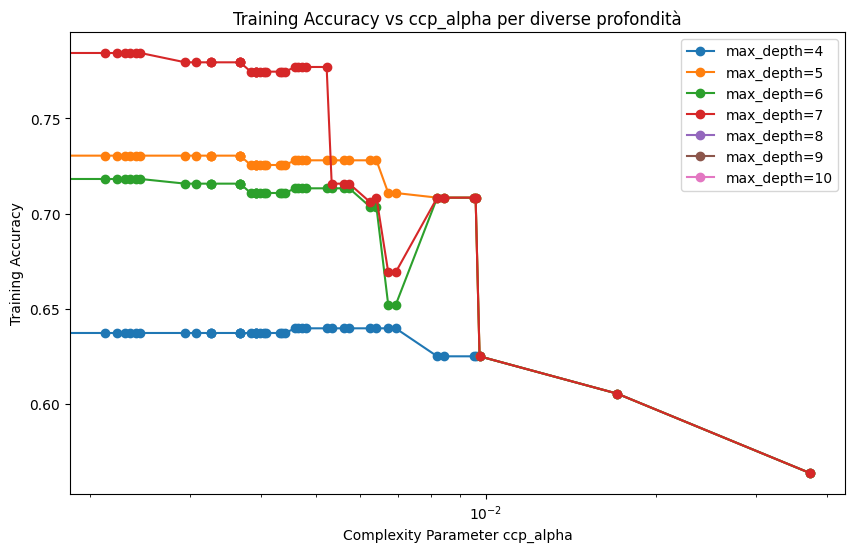

In [27]:
plt.figure(figsize=(10, 6))

for depth in range(4, 11):
    depth_results = [r for r in results if r["max_depth"] == depth]

    alphas = [r["ccp_alpha"] for r in depth_results]
    train_acc = [r["train_accuracy"] for r in depth_results]

    plt.plot(alphas, train_acc, marker="o", label=f"max_depth={depth}")

plt.xlabel("Complexity Parameter ccp_alpha")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs ccp_alpha per diverse profondità")
plt.xscale("log")
plt.legend()
plt.show()

In [28]:
best_clf = DecisionTreeClassifier(
    max_depth=best_result["max_depth"],
    ccp_alpha=best_result["ccp_alpha"],
    class_weight="balanced",
    random_state=42
)

best_clf.fit(X_train, y_train)

print("Accuracy train:", best_clf.score(X_train, y_train))
print("Accuracy test:", best_clf.score(X_test, y_test))

Accuracy train: 0.7769607843137255
Accuracy test: 0.6685714285714286


In [29]:
y_pred = best_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)
print("\nAccuracy:", cm.diagonal().sum() / cm.sum())

Confusion matrix:
 [[37 13]
 [45 80]]

Accuracy: 0.6685714285714286


In [30]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.74      0.45      0.56        82
           1       0.64      0.86      0.73        93

    accuracy                           0.67       175
   macro avg       0.69      0.66      0.65       175
weighted avg       0.69      0.67      0.65       175



### diamo un occhiata con la balancedPrecision

In [31]:
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.74      0.56        50
           1       0.86      0.64      0.73       125

    accuracy                           0.67       175
   macro avg       0.66      0.69      0.65       175
weighted avg       0.74      0.67      0.68       175

Balanced accuracy: 0.69
[[37 13]
 [45 80]]


### Andiamo a modificare l'addestramento per dare più peso ai dati minoritari

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


def train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try=None,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    pos_label=1,
    random_state=42,
    print_report=True
):
    """
    Addestra più DecisionTreeClassifier provando:
    - diverse profondità;
    - diversi valori di ccp_alpha;
    - diversi pesi manuali per le classi.

    Restituisce:
    - best_clf: modello migliore riaddestrato;
    - results_df: DataFrame con tutti i risultati;
    - best_row: riga del DataFrame corrispondente al miglior modello.
    """

    if weights_to_try is None:
        weights_to_try = [
            {0: 1, 1: 1},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
            {0: 1, 1: 10}
        ]

    results = []

    for depth in depths:
        for complexity in ccp_alphas:
            for weights in weights_to_try:

                clf = DecisionTreeClassifier(
                    max_depth=depth,
                    ccp_alpha=complexity,
                    class_weight=weights,
                    random_state=random_state
                )

                clf.fit(X_train, y_train)

                y_pred_train = clf.predict(X_train)
                y_pred_test = clf.predict(X_test)

                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
                test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

                precision_1 = precision_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                recall_1 = recall_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                f1_1 = f1_score(
                    y_test,
                    y_pred_test,
                    pos_label=pos_label,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred_test,
                    average="weighted",
                    zero_division=0
                )

                results.append({
                    "max_depth": depth,
                    "ccp_alpha": complexity,
                    "class_weight": weights,
                    "weight_0": weights.get(0, np.nan),
                    "weight_1": weights.get(1, np.nan),

                    "train_accuracy": train_acc,
                    "test_accuracy": test_acc,

                    "train_balanced_accuracy": train_bal_acc,
                    "test_balanced_accuracy": test_bal_acc,

                    "precision_class_1": precision_1,
                    "recall_class_1": recall_1,
                    "f1_class_1": f1_1,

                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                })

    results_df = pd.DataFrame(results)

    if scoring_metric not in results_df.columns:
        raise ValueError(
            f"scoring_metric non valido: {scoring_metric}. "
            f"Scegli tra: {list(results_df.columns)}"
        )

    best_index = results_df[scoring_metric].idxmax()
    best_row = results_df.loc[best_index]

    best_clf = DecisionTreeClassifier(
        max_depth=int(best_row["max_depth"]),
        ccp_alpha=best_row["ccp_alpha"],
        class_weight=best_row["class_weight"],
        random_state=random_state
    )

    best_clf.fit(X_train, y_train)

    y_pred_best = best_clf.predict(X_test)

    if print_report:
        print("Migliore configurazione trovata:")
        print(best_row)

        print("\nConfusion matrix:")
        print(confusion_matrix(y_test, y_pred_best))

        print("\nClassification report:")
        print(classification_report(y_test, y_pred_best, zero_division=0))

    return best_clf, results_df, best_row

In [33]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 4.5},
    {0: 1, 1: 5},
    {0: 1, 1: 7},
    {0: 1, 1: 9},
    {0: 1, 1: 10}
]

best_clf, results_df, best_row = train_best_weighted_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1"
)


Migliore configurazione trovata:
max_depth                             4
ccp_alpha                      0.002124
class_weight               {0: 1, 1: 9}
weight_0                              1
weight_1                            9.0
train_accuracy                 0.727941
test_accuracy                  0.714286
train_balanced_accuracy        0.525641
test_balanced_accuracy              0.5
precision_class_1              0.714286
recall_class_1                      1.0
f1_class_1                     0.833333
macro_f1                       0.416667
weighted_f1                    0.595238
Name: 20, dtype: object

Confusion matrix:
[[  0  50]
 [  0 125]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.71      1.00      0.83       125

    accuracy                           0.71       175
   macro avg       0.36      0.50      0.42       175
weighted avg       0.51      0.71      0.60  

In [34]:
y_pred_test = best_clf.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.71      1.00      0.83       125

    accuracy                           0.71       175
   macro avg       0.36      0.50      0.42       175
weighted avg       0.51      0.71      0.60       175



### Facciamo un ensemble a majority

In [35]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [36]:
def majority_vote(predictions):
    """
    predictions deve essere una lista con 3 array.

    Esempio:
    predictions = [
        predizioni_modello_1,
        predizioni_modello_2,
        predizioni_modello_3
    ]

    Ogni array contiene valori 0/1.
    """

    final_predictions = []

    n_samples = len(predictions[0])

    for i in range(n_samples):
        votes_for_1 = 0

        for model_predictions in predictions:
            if model_predictions[i] == 1:
                votes_for_1 = votes_for_1 + 1

        if votes_for_1 >= 2:
            final_predictions.append(1)
        else:
            final_predictions.append(0)

    return np.array(final_predictions)


def train_three_trees(
    X_train,
    y_train,
    max_depth,
    ccp_alpha,
    class_weight,
    random_state=42
):
    models = []

    splitter = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=random_state
    )

    fold_number = 0

    for train_index, validation_index in splitter.split(X_train, y_train):
        # Ogni albero usa i due fold di training (circa il 66% dei dati).
        X_part = X_train.iloc[train_index]
        y_part = y_train.iloc[train_index]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            class_weight=class_weight,
            random_state=random_state + fold_number
        )

        tree.fit(X_part, y_part)

        models.append(tree)

        fold_number = fold_number + 1

    return models
def predict_ensemble(models, X_test):
    predictions = []

    for model in models:
        model_predictions = model.predict(X_test)
        predictions.append(model_predictions)

    final_predictions = majority_vote(predictions)

    return final_predictions

def search_best_ensemble_tree(
    X_train,
    y_train,
    X_test,
    y_test,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
):
    results = []

    best_models = None
    best_score = -1
    best_row = None
    best_predictions = None

    for depth in depths:

        for alpha in ccp_alphas:

            for weights in weights_to_try:

                models = train_three_trees(
                    X_train=X_train,
                    y_train=y_train,
                    max_depth=depth,
                    ccp_alpha=alpha,
                    class_weight=weights,
                    random_state=random_state
                )

                y_pred = predict_ensemble(
                    models=models,
                    X_test=X_test
                )

                test_accuracy = accuracy_score(y_test, y_pred)

                test_balanced_accuracy = balanced_accuracy_score(
                    y_test,
                    y_pred
                )

                precision_class_1 = precision_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                recall_class_1 = recall_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                f1_class_1 = f1_score(
                    y_test,
                    y_pred,
                    pos_label=1,
                    zero_division=0
                )

                macro_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="macro",
                    zero_division=0
                )

                weighted_f1 = f1_score(
                    y_test,
                    y_pred,
                    average="weighted",
                    zero_division=0
                )

                row = {
                    "max_depth": depth,
                    "ccp_alpha": alpha,
                    "class_weight": weights,
                    "weight_0": weights[0],
                    "weight_1": weights[1],
                    "accuracy": test_accuracy,
                    "balanced_accuracy": test_balanced_accuracy,
                    "precision_class_1": precision_class_1,
                    "recall_class_1": recall_class_1,
                    "f1_class_1": f1_class_1,
                    "macro_f1": macro_f1,
                    "weighted_f1": weighted_f1
                }

                results.append(row)

                current_score = row[scoring_metric]

                if current_score > best_score:
                    best_score = current_score
                    best_models = models
                    best_row = row
                    best_predictions = y_pred

    results_df = pd.DataFrame(results)

    print("Migliore configurazione trovata:")
    print(best_row)

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, best_predictions))

    print("\nClassification report:")
    print(classification_report(y_test, best_predictions, zero_division=0))

    print("Metrica usata per scegliere:", scoring_metric)
    print("Valore migliore:", best_score)

    return best_models, results_df, best_row, best_predictions


In [37]:
weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 2.5},
    {0: 1, 1: 3},
    {0: 1, 1: 4},
    {0: 1, 1: 5}
]


#clean_training_results[] = best_models, results_df, best_row, best_predictions

best_models, results_df, best_row, best_predictions = search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)
clean_training_results = best_models, results_df, best_row, best_predictions

Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.006403334280572135), 'class_weight': {0: 1, 1: 2.5}, 'weight_0': 1, 'weight_1': 2.5, 'accuracy': 0.72, 'balanced_accuracy': 0.516, 'precision_class_1': 0.7209302325581395, 'recall_class_1': 0.992, 'f1_class_1': 0.835016835016835, 'macro_f1': 0.45524426656502126, 'weighted_f1': 0.6180039387586557}

Confusion matrix:
[[  2  48]
 [  1 124]]

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.04      0.08        50
           1       0.72      0.99      0.84       125

    accuracy                           0.72       175
   macro avg       0.69      0.52      0.46       175
weighted avg       0.71      0.72      0.62       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.835016835016835


In [38]:
results_df.sort_values(
    by="f1_class_1",
    ascending=False
).head(10)

,max_depth,ccp_alpha,class_weight,weight_0,weight_1,accuracy,balanced_accuracy,precision_class_1,recall_class_1,f1_class_1,macro_f1,weighted_f1
255,4,0.006403,"{0: 1, 1: 2.5}",1,2.5,0.720000,0.516,0.720930,0.992,0.835017,0.455244,0.618004
1207,7,0.005731,"{0: 1, 1: 2.5}",1,2.5,0.725714,0.544,0.733333,0.968,0.834483,0.517241,0.653202
1200,7,0.005610,"{0: 1, 1: 2.5}",1,2.5,0.725714,0.544,0.733333,0.968,0.834483,0.517241,0.653202
1186,7,0.005229,"{0: 1, 1: 2.5}",1,2.5,0.725714,0.544,0.733333,0.968,0.834483,0.517241,0.653202
1193,7,0.005338,"{0: 1, 1: 2.5}",1,2.5,0.725714,0.544,0.733333,0.968,0.834483,0.517241,0.653202
1287,7,0.037347,"{0: 1, 1: 5}",1,5.0,0.714286,0.500,0.714286,1.000,0.833333,0.416667,0.595238
1271,7,0.009743,"{0: 1, 1: 3}",1,3.0,0.714286,0.500,0.714286,1.000,0.833333,0.416667,0.595238
291,4,0.009526,"{0: 1, 1: 3}",1,3.0,0.714286,0.500,0.714286,1.000,0.833333,0.416667,0.595238
292,4,0.009526,"{0: 1, 1: 4}",1,4.0,0.714286,0.500,0.714286,1.000,0.833333,0.416667,0.595238
293,4,0.009526,"{0: 1, 1: 5}",1,5.0,0.714286,0.500,0.714286,1.000,0.833333,0.416667,0.595238


In [39]:
y_pred = predict_ensemble(
                    models=best_models,
                    X_test=X_test
                )
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.67      0.04      0.08        50
           1       0.72      0.99      0.84       125

    accuracy                           0.72       175
   macro avg       0.69      0.52      0.46       175
weighted avg       0.71      0.72      0.62       175



### gestione pesi per classe

In [40]:
n_estimators_to_try = [100, 200, 300, 500]

depths_to_try = [4, 5, 6, 7, 8, None]

weights_to_try = [
    {0: 1, 1: 1},
    {0: 1, 1: 1.5},
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    "balanced"
]

# best_rf, rf_results_df, best_rf_row, y_pred_rf = search_best_random_forest(
#     X_train,
#     y_train,
#     X_test,
#     y_test,
#     n_estimators_to_try=n_estimators_to_try,
#     depths_to_try=depths_to_try,
#     weights_to_try=weights_to_try,
#     scoring_metric="macro_f1"
# )

### Sporchiamo Il Dataset

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def corrupt_rows_cat(X_train, col, frac=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    unique_values = X_train_corrupt[col].unique()

    if len(unique_values) <= 1:
        print(f"Attenzione: la colonna '{col}' ha un solo valore unico. Nessuna modifica applicata.")
        return X_train_corrupt

    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    if n_rows_to_corrupt == 0:
        return X_train_corrupt

    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        pool_of_new_values = unique_values[unique_values != current_value]

        X_train_corrupt.at[idx, col] = rng.choice(pool_of_new_values)

    return X_train_corrupt


def corrupt_rows_cont(X_train, col, frac=0.1, noise_level=0.1, random_state=None):
    X_train_corrupt = X_train.copy()

    rng = np.random.default_rng(random_state)

    X_train_corrupt[col] = X_train_corrupt[col].astype(float)

    n_rows_to_corrupt = int(frac * len(X_train_corrupt))

    if n_rows_to_corrupt == 0:
        return X_train_corrupt

    indices_to_corrupt = rng.choice(
        X_train_corrupt.index,
        size=n_rows_to_corrupt,
        replace=False
    )

    std_col = X_train_corrupt[col].std()

    if std_col == 0:
        print(f"Attenzione: la colonna '{col}' ha deviazione standard 0. Nessuna modifica applicata.")
        return X_train_corrupt

    for idx in indices_to_corrupt:
        current_value = X_train_corrupt.at[idx, col]

        noise = rng.normal(
            loc=0,
            scale=noise_level * std_col
        )

        X_train_corrupt.at[idx, col] = current_value + noise

    return X_train_corrupt




I0000 00:00:1783005430.646547  153736 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783005430.651471  153736 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783005431.185527  153736 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783005432.752130  153736 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

### mostro le variabili dalla più importante alla meno importante

In [42]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import pandas as pd

# La Mutual Information viene calcolata solo sul training set.
X_mi = df_encoded.drop(columns=["Selector"])
y_mi = df_encoded["Selector"]

X_mi_train_val, _, y_mi_train_val, _ = train_test_split(
    X_mi,
    y_mi,
    test_size=0.3,
    random_state=42,
    stratify=y_mi
)

X_mi_train, _, y_mi_train, _ = train_test_split(
    X_mi_train_val,
    y_mi_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_mi_train_val
)

# colonne categoriche
categoriche = ["Gender"]

# True per le categoriche, False per le continue
discrete_mask = []

for col in X_mi_train.columns:
    if col in categoriche:
        discrete_mask.append(True)
    else:
        discrete_mask.append(False)

# calcolo mutual information
mi = mutual_info_classif(
    X_mi_train,
    y_mi_train,
    discrete_features=discrete_mask,
    random_state=42
)

# creo tabella ordinata
importanza_variabili = pd.DataFrame({
    "variabile": X_mi_train.columns,
    "importanza": mi
})

importanza_variabili = importanza_variabili.sort_values(
    by="importanza",
    ascending=False
)

print(importanza_variabili)

   variabile  importanza
0        Age    0.095804
6       Sgot    0.055838
4    Alkphos    0.049570
3         DB    0.038744
2         TB    0.038151
5       Sgpt    0.026230
7         TP    0.007131
1     Gender    0.001745
8        ALB    0.000000
9  A/G Ratio    0.000000


In [43]:
feature_ordinate = importanza_variabili["variabile"].tolist()
n = len(feature_ordinate)
meta = n // 2

if n % 2 == 0:
    migliori = feature_ordinate[:meta]
    peggiori = feature_ordinate[meta:]
else:
    # la feature centrale appartiene a entrambe le liste
    migliori = feature_ordinate[:meta + 1]
    peggiori = feature_ordinate[meta:]

print("Migliori:", migliori)
print("Peggiori:", peggiori)

Migliori: ['Age', 'Sgot', 'Alkphos', 'DB', 'TB']
Peggiori: ['Sgpt', 'TP', 'Gender', 'ALB', 'A/G Ratio']


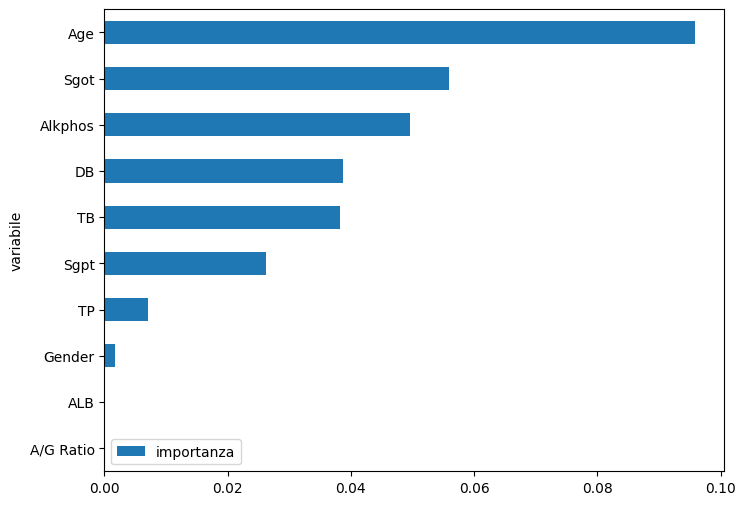

In [44]:
import matplotlib.pyplot as plt

importanza_variabili.plot(
    kind="barh",
    x="variabile",
    y="importanza",
    figsize=(8, 6)
)

plt.gca().invert_yaxis()
plt.show()

### Proviamo a sporcare la feature SGPT in maniera progressiva mentre lo addestriamo e vediamo di quanto cala la performance del modello

In [45]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [46]:
## AG ratio è continua, voglio quindi usare la funzione che sporca colonno continue
# una volta sporcata faccio partire un giro di training su ensemble
# dopo di che faccio una valutazione del modello e la confronto con il modello addestrato sul dataset non sporco

In [47]:
non_corrupted_data = [X_train, X_test, y_train, y_test]

In [48]:
# df_corrotto = corrupt_rows_cont(
#     df_encoded,
#     col="Sgpt",
#     frac=0.2,
#     noise_level=0.1,
#     random_state=42
# )

In [49]:
noise_training_results = [] #best_models, results_df, best_row, best_predictions 

noise_training_results= search_best_ensemble_tree(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ccp_alphas=ccp_alphas,
    weights_to_try=weights_to_try,
    depths=range(4, 8),
    scoring_metric="f1_class_1",
    random_state=42
)

Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.0043218954248365965), 'class_weight': {0: 1, 1: 5}, 'weight_0': 1, 'weight_1': 5, 'accuracy': 0.7142857142857143, 'balanced_accuracy': 0.5, 'precision_class_1': 0.7142857142857143, 'recall_class_1': 1.0, 'f1_class_1': 0.8333333333333334, 'macro_f1': 0.4166666666666667, 'weighted_f1': 0.5952380952380952}

Confusion matrix:
[[  0  50]
 [  0 125]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.71      1.00      0.83       125

    accuracy                           0.71       175
   macro avg       0.36      0.50      0.42       175
weighted avg       0.51      0.71      0.60       175

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.8333333333333334


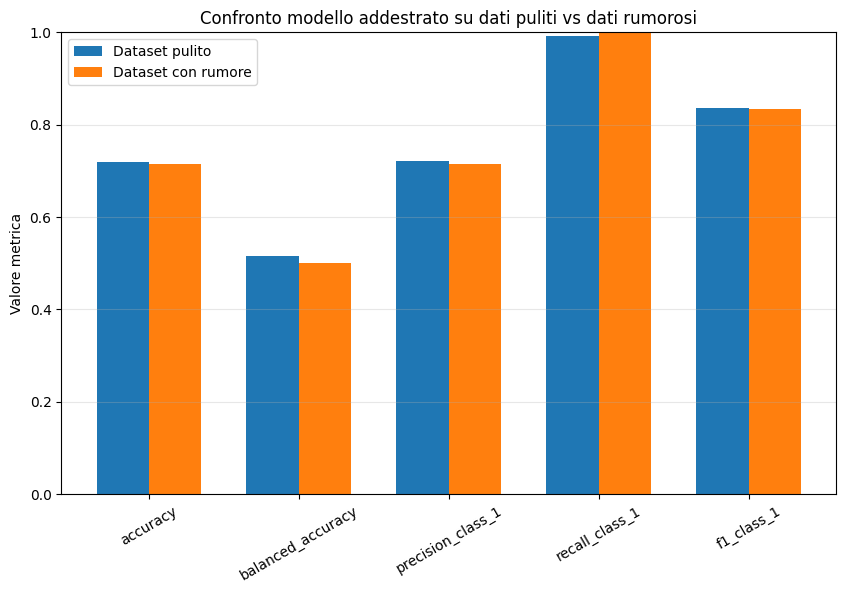

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Risultati modello pulito
clean_best_models, clean_results_df, clean_best_row, clean_best_predictions = clean_training_results

# Risultati modello con rumore
noise_best_models, noise_results_df, noise_best_row, noise_best_predictions = noise_training_results


# Funzione per trasformare best_row sempre in dizionario
def best_row_to_dict(best_row):
    if isinstance(best_row, pd.DataFrame):
        return best_row.iloc[0].to_dict()
    
    if isinstance(best_row, pd.Series):
        return best_row.to_dict()
    
    if isinstance(best_row, dict):
        return best_row
    
    raise TypeError("best_row deve essere un dict, una Series o un DataFrame")


clean_best_row = best_row_to_dict(clean_best_row)
noise_best_row = best_row_to_dict(noise_best_row)


# Metriche che voglio confrontare
possible_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_class_1",
    "recall_class_1",
    "f1_class_1"
]

# Tengo solo le metriche presenti in entrambi
metrics = []

for metric in possible_metrics:
    if metric in clean_best_row.keys() and metric in noise_best_row.keys():
        metrics.append(metric)


# Valori delle metriche
clean_values = []

for metric in metrics:
    clean_values.append(clean_best_row[metric])


noise_values = []

for metric in metrics:
    noise_values.append(noise_best_row[metric])


# Grafico
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, clean_values, width, label="Dataset pulito")
plt.bar(x + width/2, noise_values, width, label="Dataset con rumore")

plt.xticks(x, metrics, rotation=30)
plt.ylabel("Valore metrica")
plt.title("Confronto modello addestrato su dati puliti vs dati rumorosi")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [51]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [52]:

# X_train, X_test, y_train, y_test = train_test_split_with_undersampling(
#     df=df_encoded,
#     target_col="Gender",
#     test_size=0.7,
#     random_state=42,
#     stratify=False
# )



In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# La classe 0 (nessuna malattia) è minoritaria dopo il mapping esplicito.
tree_weights_to_try = [
    {0: 1, 1: 1},
    {0: 1.5, 1: 1},
    {0: 2, 1: 1},
    {0: 2.5, 1: 1},
    {0: 3, 1: 1},
    {0: 4, 1: 1},
    {0: 5, 1: 1}
]


def test_noise_progressivo(
    df,
    target_col,
    cols_to_corrupt,
    ccp_alphas,
    weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non devi sporcare la colonna target.")

    # Split train/validation/test. Il test non partecipa alla selezione.
    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    # ✔ identificazione tipo colonne
    tipo_colonne = {}

    for col in cols_to_corrupt:

        is_categorical = (
            col in categorical_cols or
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool" or
            (
                pd.api.types.is_integer_dtype(df[col]) and
                df[col].nunique() <= max_unique_for_cat
            )
        )

        tipo_colonne[col] = is_categorical

    print("Colonne da corrompere:")
    for col, is_cat in tipo_colonne.items():
        print(f" - {col}: {'categorica' if is_cat else 'continua'}")

    # ✔ rumore progressivo (include 0%)
    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        # reset train base
        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # ✔ applicazione rumore su più colonne
        for col_index, col in enumerate(cols_to_corrupt):

            # Seed diverso per colonna, stabile tra i livelli di rumore.
            column_seed = random_state + col_index

            if tipo_colonne[col]:

                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=column_seed
                )

            else:

                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=column_seed
                )

        # ✔ training modello (ensemble tree search invariato)
        training_results = search_best_ensemble_tree(
            X_train=X_train,
            y_train=y_train,
            # La configurazione viene scelta sul validation set.
            X_test=X_val,
            y_test=y_val,
            ccp_alphas=ccp_alphas,
            weights_to_try=weights_to_try,
            depths=depths,
            scoring_metric=scoring_metric,
            random_state=random_state
        )

        best_models, results_df, best_row, validation_predictions = training_results

        # Il test set viene usato soltanto dopo la selezione dei parametri.
        best_predictions = predict_ensemble(best_models, X_test)
        accuracy = accuracy_score(y_test, best_predictions)
        balanced_accuracy = balanced_accuracy_score(y_test, best_predictions)
        precision = precision_score(y_test, best_predictions, pos_label=1, zero_division=0)
        recall = recall_score(y_test, best_predictions, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, best_predictions, pos_label=1, zero_division=0)

        # ✔ normalizzazione best_row
        if isinstance(best_row, pd.DataFrame):
            best_row_dict = best_row.iloc[0].to_dict()
        elif isinstance(best_row, pd.Series):
            best_row_dict = best_row.to_dict()
        elif isinstance(best_row, dict):
            best_row_dict = best_row.copy()
        else:
            raise TypeError("best_row formato non valido")

        best_row_dict.update({
            "accuracy": accuracy,
            "balanced_accuracy": balanced_accuracy,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "f1_class_1": f1,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "tipo_colonne": str(tipo_colonne),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_finali.append(best_row_dict)

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train,
            "y_val": y_val,
            "y_test": y_test,
            "best_models": best_models,
            "results_df": results_df,
            "best_row": best_row,
            "best_predictions": best_predictions,
            "accuracy": accuracy
        }

    # ✔ dataframe finale
    risultati_df = pd.DataFrame(risultati_finali)

    # ✔ metriche disponibili
    metriche_possibili = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    metriche_presenti = [
        m for m in metriche_possibili if m in risultati_df.columns
    ]

    print(risultati_df)

    # ✔ grafico
    plt.figure(figsize=(10, 6))

    for m in metriche_presenti:

        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale di rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza ensemble alberi su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.xticks(risultati_df["percentuale_rumore"])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return risultati_df, risultati_completi

In [54]:
df_encoded.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Colonne da corrompere:
 - Sgpt: continua
 - TP: continua
 - Gender: categorica
 - ALB: continua
 - A/G Ratio: continua

Rumore: 0%
Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.03734733477657032), 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'accuracy': 0.7073170731707317, 'balanced_accuracy': 0.5, 'precision_class_1': 0.7073170731707317, 'recall_class_1': 1.0, 'f1_class_1': 0.8285714285714286, 'macro_f1': 0.4142857142857143, 'weighted_f1': 0.5860627177700348}

Confusion matrix:
[[ 0 24]
 [ 0 58]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.71      1.00      0.83        58

    accuracy                           0.71        82
   macro avg       0.35      0.50      0.41        82
weighted avg       0.50      0.71      0.59        82

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.8285714285714286

Rumore: 10%
Migliore con

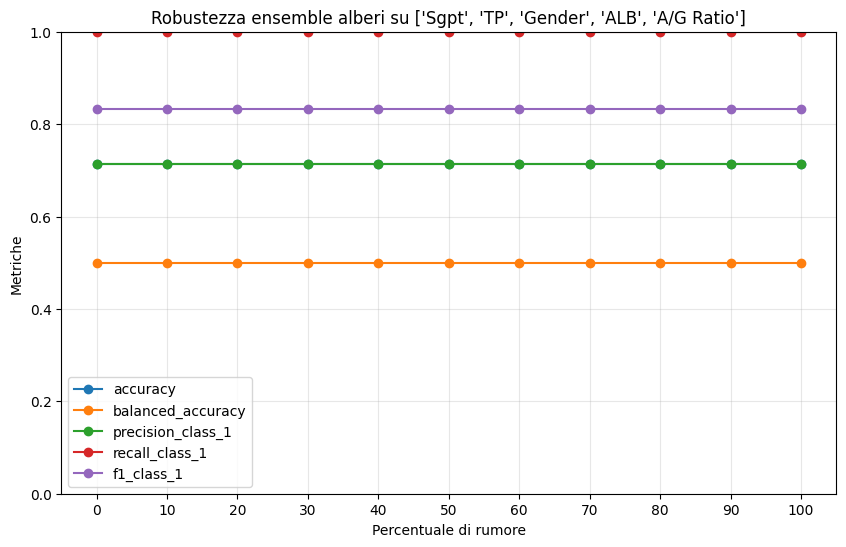

In [55]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=peggiori,
    ccp_alphas=ccp_alphas,
    weights_to_try=tree_weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=True
)


Colonne da corrompere:
 - Age: continua
 - Sgot: continua
 - Alkphos: continua
 - DB: continua
 - TB: continua

Rumore: 0%
Migliore configurazione trovata:
{'max_depth': 4, 'ccp_alpha': np.float64(0.03734733477657032), 'class_weight': {0: 1, 1: 1}, 'weight_0': 1, 'weight_1': 1, 'accuracy': 0.7073170731707317, 'balanced_accuracy': 0.5, 'precision_class_1': 0.7073170731707317, 'recall_class_1': 1.0, 'f1_class_1': 0.8285714285714286, 'macro_f1': 0.4142857142857143, 'weighted_f1': 0.5860627177700348}

Confusion matrix:
[[ 0 24]
 [ 0 58]]

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.71      1.00      0.83        58

    accuracy                           0.71        82
   macro avg       0.35      0.50      0.41        82
weighted avg       0.50      0.71      0.59        82

Metrica usata per scegliere: f1_class_1
Valore migliore: 0.8285714285714286

Rumore: 10%
Migliore configurazi

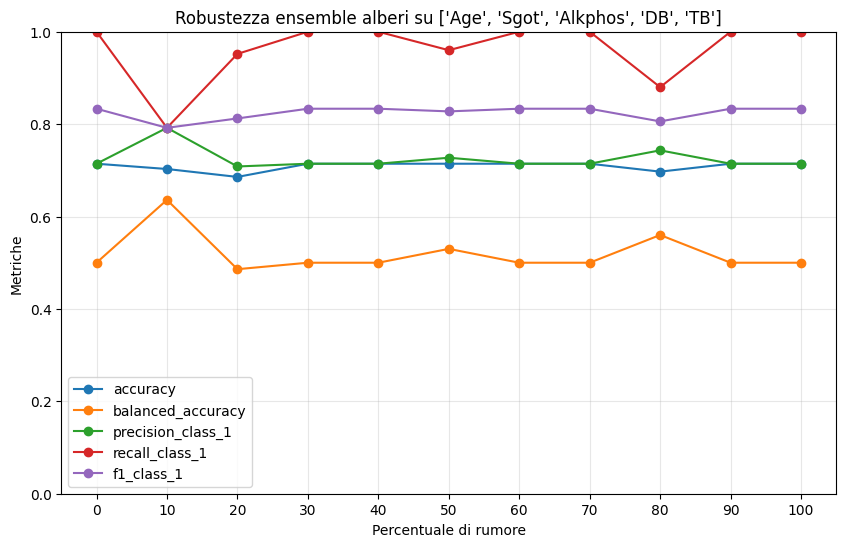

In [56]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=migliori,
    ccp_alphas=ccp_alphas,
    weights_to_try=tree_weights_to_try,
    depths=range(4, 8),
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    scoring_metric="f1_class_1",
    stratify=True
)

Inizio rete neurale


In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf


In [58]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [59]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
import numpy as np
from sklearn.metrics import confusion_matrix

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

y_pred = model.predict(X_test)

# conversione probabilità in classi
y_pred = (y_pred > 0.5).astype(int)



cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1783005779.975204  153736 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Confusion matrix:
 [[ 13  37]
 [ 11 114]]

Accuracy: 0.7257142857142858


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_NN(input_dim, seed=None):
    tf.keras.backend.clear_session()

    if seed is not None:
        tf.keras.utils.set_random_seed(seed)

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return model


def ensemble_predict_NN(models, X):
    preds = []

    for m in models:
        preds.append(m.predict(X, verbose=0))

    mean_pred = np.mean(preds, axis=0)

    return (mean_pred > 0.5).astype(int).flatten()


def test_noise_progressivo_NN(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.5,
    test_size=0.3,
    validation_size=0.2,
    random_state=42,
    stratify=False,
    categorical_cols=None,
    max_unique_for_cat=10,
    feature_group=None,
    n_repeats=5,
    ensemble_size=3
):
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.utils.class_weight import compute_class_weight

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    if target_col in cols_to_corrupt:
        raise ValueError("Non puoi sporcare il target")

    X = df.drop(columns=[target_col])

    # Correzione locale: 1 = Liver Disease, 0 = No Liver Disease.
    # Il preprocessing precedente al noise experiment rimane invariato.
    y = 1 - df[target_col].astype(int)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    X_train_full, X_val, y_train_full, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_val if stratify else None
    )

    # I gruppi di feature vengono determinati usando soltanto il training set.
    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        discrete_mask = [col == "Gender" for col in X_train_full.columns]
        mi = mutual_info_classif(
            X_train_full,
            y_train_full,
            discrete_features=discrete_mask,
            random_state=random_state
        )
        ordered_features = [
            col for _, col in sorted(
                zip(mi, X_train_full.columns), reverse=True
            )
        ]
        middle = len(ordered_features) // 2
        cols_to_corrupt = (
            ordered_features[:middle]
            if feature_group == "migliori"
            else ordered_features[middle:]
        )

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {col: is_cat(col) for col in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, categorical in tipo_colonne.items():
        print(f" - {col}: {'categorica' if categorical else 'continua'}")

    classes = np.sort(y_train_full.unique())
    balanced_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_full
    )
    class_weights = dict(zip(classes, balanced_weights))
    print("Class weights:", class_weights)

    percentuali_rumore = [
        0, 0.1, 0.2, 0.3, 0.4, 0.5,
        0.6, 0.7, 0.8, 0.9, 1.0
    ]
    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    for frac in percentuali_rumore:
        percentuale = int(frac * 100)
        print(f"\nRumore: {percentuale}%")
        repeat_metrics = []
        repeat_details = []

        for repeat in range(n_repeats):
            X_train = X_train_full.copy()
            y_train = y_train_full.copy()

            # Seed diverso per colonna e ripetizione, ma costante tra i livelli.
            for col_index, col in enumerate(cols_to_corrupt):
                column_seed = random_state + repeat * 1000 + col_index
                if tipo_colonne[col]:
                    X_train = corrupt_rows_cat(
                        X_train,
                        col=col,
                        frac=frac,
                        random_state=column_seed
                    )
                else:
                    X_train = corrupt_rows_cont(
                        X_train,
                        col=col,
                        frac=frac,
                        noise_level=noise_level,
                        random_state=column_seed
                    )

            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)

            models = []
            model_seeds = []

            for model_index in range(ensemble_size):
                # Lo stesso repeat/model usa bootstrap e inizializzazione uguali
                # per tutti i livelli: cambia soltanto il rumore nei dati.
                seed_i = random_state + repeat * 1000 + model_index
                model_seeds.append(seed_i)
                rng_bootstrap = np.random.default_rng(seed_i)
                idx = rng_bootstrap.choice(
                    len(X_train_scaled),
                    len(X_train_scaled),
                    replace=True
                )

                X_boot = X_train_scaled[idx]
                y_boot = y_train.iloc[idx].to_numpy()
                model = build_model_NN(
                    input_dim=X_train_scaled.shape[1],
                    seed=seed_i
                )
                model.fit(
                    X_boot,
                    y_boot,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_val_scaled, y_val),
                    class_weight=class_weights,
                    callbacks=[tf.keras.callbacks.EarlyStopping(
                        monitor="val_loss",
                        patience=5,
                        restore_best_weights=True
                    )],
                    verbose=0,
                    shuffle=True
                )
                models.append(model)

            y_pred = ensemble_predict_NN(models, X_test_scaled)
            metrics = {
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "precision_class_1": precision_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "recall_class_1": recall_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                ),
                "f1_class_1": f1_score(
                    y_test, y_pred, pos_label=1, zero_division=0
                )
            }
            repeat_metrics.append(metrics)
            repeat_details.append({
                "repeat": repeat,
                "model_seeds": model_seeds,
                "y_pred": y_pred,
                "metrics": metrics
            })

            # Non conserviamo i modelli Keras di tutti i repeat in memoria.
            del models

        result = {
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": percentuale,
            "n_repeats": n_repeats
        }
        for metric in metric_names:
            values = np.array([row[metric] for row in repeat_metrics])
            result[metric] = values.mean()
            result[f"{metric}_std"] = values.std(ddof=1) if n_repeats > 1 else 0.0

        risultati_finali.append(result)
        risultati_completi[percentuale] = {
            "X_train_clean": X_train_full,
            "X_val": X_val,
            "X_test": X_test,
            "y_train": y_train_full,
            "y_val": y_val,
            "y_test": y_test,
            "class_weights": class_weights,
            "repeats": repeat_details
        }

    risultati_df = pd.DataFrame(risultati_finali)

    plt.figure(figsize=(10, 6))
    for metric in metric_names:
        plt.errorbar(
            risultati_df["percentuale_rumore"],
            risultati_df[metric],
            yerr=risultati_df[f"{metric}_std"],
            marker="o",
            capsize=3,
            label=metric
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche (media ± deviazione standard)")
    plt.title(f"Robustezza NN ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)
    return risultati_df, risultati_completi


Colonne da corrompere:
 - A/G Ratio: continua
 - TB: continua
 - Alkphos: continua
 - Gender: categorica
 - TP: continua
Class weights: {np.int64(0): np.float64(0.6995708154506438), np.int64(1): np.float64(1.7526881720430108)}

Rumore: 0%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 10%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 20%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 30%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 40%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 50%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 60%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 70%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 80%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 90%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 100%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

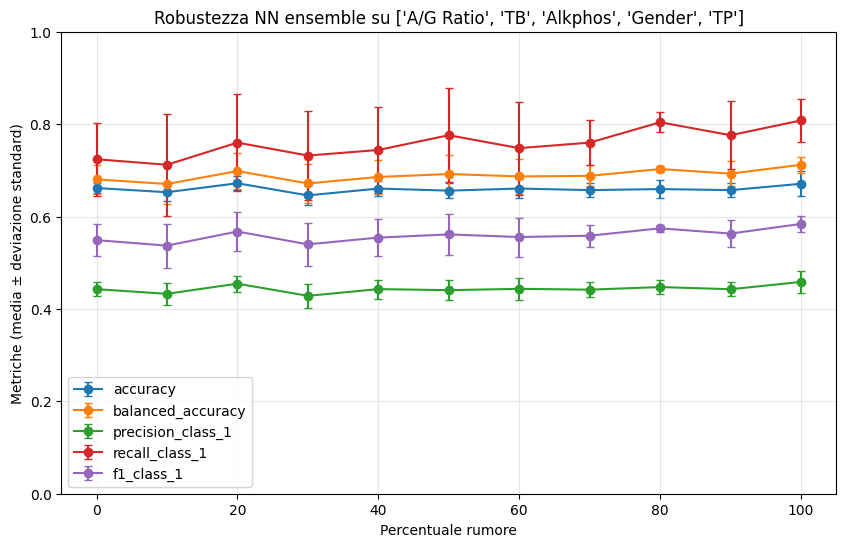

                  colonne_sporcate  frac_rumore  percentuale_rumore  \
0   A/G Ratio,TB,Alkphos,Gender,TP          0.0                   0   
1   A/G Ratio,TB,Alkphos,Gender,TP          0.1                  10   
2   A/G Ratio,TB,Alkphos,Gender,TP          0.2                  20   
3   A/G Ratio,TB,Alkphos,Gender,TP          0.3                  30   
4   A/G Ratio,TB,Alkphos,Gender,TP          0.4                  40   
5   A/G Ratio,TB,Alkphos,Gender,TP          0.5                  50   
6   A/G Ratio,TB,Alkphos,Gender,TP          0.6                  60   
7   A/G Ratio,TB,Alkphos,Gender,TP          0.7                  70   
8   A/G Ratio,TB,Alkphos,Gender,TP          0.8                  80   
9   A/G Ratio,TB,Alkphos,Gender,TP          0.9                  90   
10  A/G Ratio,TB,Alkphos,Gender,TP          1.0                 100   

    n_repeats  accuracy  accuracy_std  balanced_accuracy  \
0           5  0.661714      0.010992             0.6804   
1           5  0.652571    

In [62]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="peggiori",
    n_repeats=5,
    stratify=True,
)

Colonne da corrompere:
 - Sgpt: continua
 - Age: continua
 - DB: continua
 - ALB: continua
 - Sgot: continua
Class weights: {np.int64(0): np.float64(0.6995708154506438), np.int64(1): np.float64(1.7526881720430108)}

Rumore: 0%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 10%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 20%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 30%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 40%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 50%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 60%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 70%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 80%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 90%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 


Rumore: 100%


/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/samuele/miniforge3/envs/archi/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
 

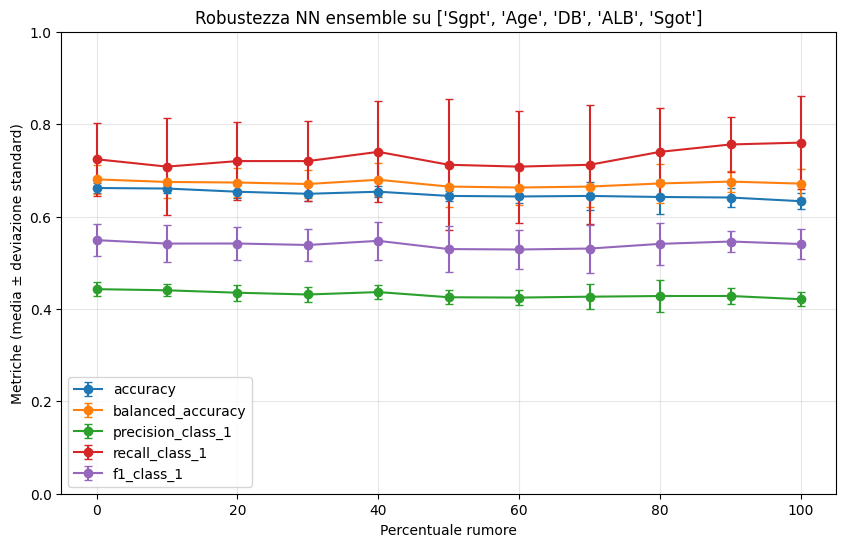

        colonne_sporcate  frac_rumore  percentuale_rumore  n_repeats  \
0   Sgpt,Age,DB,ALB,Sgot          0.0                   0          5   
1   Sgpt,Age,DB,ALB,Sgot          0.1                  10          5   
2   Sgpt,Age,DB,ALB,Sgot          0.2                  20          5   
3   Sgpt,Age,DB,ALB,Sgot          0.3                  30          5   
4   Sgpt,Age,DB,ALB,Sgot          0.4                  40          5   
5   Sgpt,Age,DB,ALB,Sgot          0.5                  50          5   
6   Sgpt,Age,DB,ALB,Sgot          0.6                  60          5   
7   Sgpt,Age,DB,ALB,Sgot          0.7                  70          5   
8   Sgpt,Age,DB,ALB,Sgot          0.8                  80          5   
9   Sgpt,Age,DB,ALB,Sgot          0.9                  90          5   
10  Sgpt,Age,DB,ALB,Sgot          1.0                 100          5   

    accuracy  accuracy_std  balanced_accuracy  balanced_accuracy_std  \
0   0.661714      0.010992             0.6804               0.0

In [63]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_NN(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="migliori",
    n_repeats=5,
    stratify=True,
)

Inizio svg

In [64]:
y = df_encoded["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded[feature_names], df_encoded[target_name], test_size=0.3, random_state=42, stratify=y)

In [65]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Creazione del modello SVM
model = SVC(
    kernel="rbf",        
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

# Addestramento
model.fit(X_train, y_train)

# Predizioni
y_pred = model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:\n", cm)

accuracy = cm.diagonal().sum() / cm.sum()
print("\nAccuracy:", accuracy)

Confusion matrix:
 [[46  4]
 [60 65]]

Accuracy: 0.6342857142857142


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score
)


def build_model_SVM():
    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    )
    return model


def ensemble_predict_SVM(models, X):

    preds = []

    for m in models:
        preds.append(m.predict(X))

    preds = np.array(preds)

    # Majority voting
    y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

    return y_pred




def test_noise_progressivo_SVM(
    df,
    target_col,
    cols_to_corrupt,
    noise_level=0.1,
    test_size=0.3,
    random_state=42,
    stratify=False,
    feature_group=None,
    categorical_cols=None,
    max_unique_for_cat=10
):

    risultati_finali = []
    risultati_completi = {}

    if categorical_cols is None:
        categorical_cols = []

    if isinstance(cols_to_corrupt, str):
        cols_to_corrupt = [cols_to_corrupt]

    for c in cols_to_corrupt:
        if c == target_col:
            raise ValueError("Non puoi sporcare il target")

    def is_cat(col):
        if col in categorical_cols:
            return True
        if (
            df[col].dtype == "object" or
            str(df[col].dtype) == "category" or
            df[col].dtype == "bool"
        ):
            return True
        if pd.api.types.is_integer_dtype(df[col]):
            return df[col].nunique() <= max_unique_for_cat
        return False

    tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    # SPLIT UNA SOLA VOLTA (FIX come NN)
    X = df.drop(columns=[target_col])
    # Correzione locale: 1 = Liver Disease, 0 = No Liver Disease.
    y = 1 - df[target_col].astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if stratify else None
    )

    # La selezione delle feature usa soltanto il training set.
    if feature_group is not None:
        if feature_group not in {"migliori", "peggiori"}:
            raise ValueError("feature_group deve essere 'migliori' o 'peggiori'")

        discrete_mask = [col == "Gender" for col in X_train_full.columns]
        mi = mutual_info_classif(
            X_train_full,
            y_train_full,
            discrete_features=discrete_mask,
            random_state=random_state
        )
        ordered_features = [
            col for _, col in sorted(
                zip(mi, X_train_full.columns), reverse=True
            )
        ]
        middle = len(ordered_features) // 2
        cols_to_corrupt = (
            ordered_features[:middle]
            if feature_group == "migliori"
            else ordered_features[middle:]
        )
        tipo_colonne = {c: is_cat(c) for c in cols_to_corrupt}

    print("Colonne da corrompere:")
    for col, categorical in tipo_colonne.items():
        print(f" - {col}: {'categorica' if categorical else 'continua'}")

    percentuali_rumore = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for frac in percentuali_rumore:

        print(f"\nRumore: {int(frac*100)}%")

        X_train = X_train_full.copy()
        y_train = y_train_full.copy()

        # CORRUZIONE
        for col_index, col in enumerate(cols_to_corrupt):

            # Seed diverso per colonna, stabile tra i livelli di rumore.
            column_seed = random_state + col_index

            if tipo_colonne[col]:
                X_train = corrupt_rows_cat(
                    X_train,
                    col=col,
                    frac=frac,
                    random_state=column_seed
                )
            else:
                X_train = corrupt_rows_cont(
                    X_train,
                    col=col,
                    frac=frac,
                    noise_level=noise_level,
                    random_state=column_seed
                )

        # Scaling stimato esclusivamente sul training del livello corrente.
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        models = []

        # ENSEMBLE CON BOOTSTRAP (FIX come NN)
        for i in range(3):


            # quesra riga non va bene, non ha un seed
            #idx = np.random.choice(len(X_train), len(X_train), replace=True)
            #fix:
            seed_i = random_state + i
            rng = np.random.default_rng(seed_i)

            idx = rng.choice(
                len(X_train_scaled),
                len(X_train_scaled),
                replace=True
            )

            X_boot = X_train_scaled[idx]
            y_boot = y_train.iloc[idx].to_numpy()

            model = SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced"
            )

            model.fit(X_boot, y_boot)

            models.append(model)

        # PREDIZIONE ENSEMBLE (majority vote coerente)
        preds = []

        for m in models:
            preds.append(m.predict(X_test_scaled))

        preds = np.array(preds)

        y_pred = (np.mean(preds, axis=0) >= 0.5).astype(int)

        # METRICHE
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)

        risultati_finali.append({
            "accuracy": accuracy,
            "f1_class_1": f1,
            "precision_class_1": precision,
            "recall_class_1": recall,
            "balanced_accuracy": balanced_acc,
            "colonne_sporcate": ",".join(cols_to_corrupt),
            "frac_rumore": frac,
            "percentuale_rumore": int(frac * 100)
        })

        risultati_completi[int(frac * 100)] = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "models": models,
            "scaler": scaler,
            "y_pred": y_pred
        }

    risultati_df = pd.DataFrame(risultati_finali)

    # GRAFICO IDENTICO NN
    metriche = [
        "accuracy",
        "balanced_accuracy",
        "precision_class_1",
        "recall_class_1",
        "f1_class_1"
    ]

    plt.figure(figsize=(10, 6))

    for m in metriche:
        plt.plot(
            risultati_df["percentuale_rumore"],
            risultati_df[m],
            marker="o",
            label=m
        )

    plt.xlabel("Percentuale rumore")
    plt.ylabel("Metriche")
    plt.title(f"Robustezza SVM ensemble su {cols_to_corrupt}")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(risultati_df)

    return risultati_df, risultati_completi

Colonne da corrompere:
 - Sgot: continua
 - Alkphos: continua
 - TP: continua
 - Gender: categorica
 - A/G Ratio: continua

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


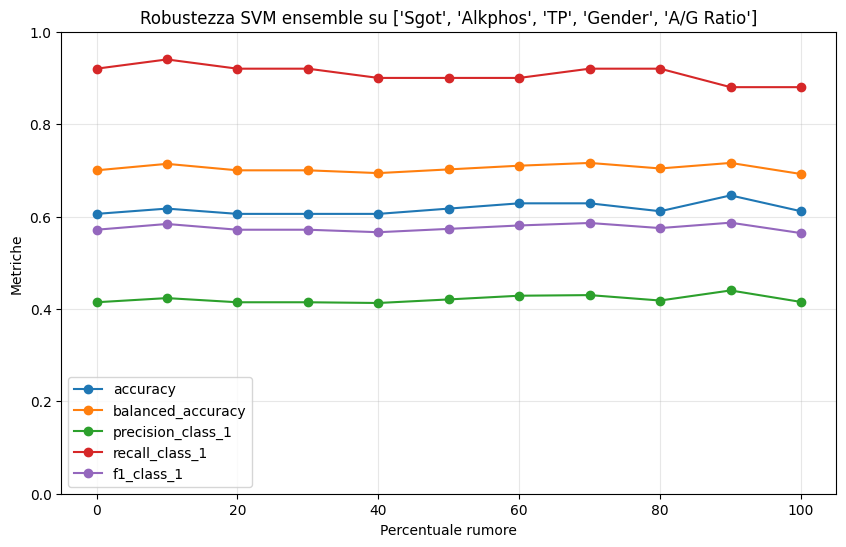

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.605714    0.571429           0.414414            0.92   
1   0.617143    0.583851           0.423423            0.94   
2   0.605714    0.571429           0.414414            0.92   
3   0.605714    0.571429           0.414414            0.92   
4   0.605714    0.566038           0.412844            0.90   
5   0.617143    0.573248           0.420561            0.90   
6   0.628571    0.580645           0.428571            0.90   
7   0.628571    0.585987           0.429907            0.92   
8   0.611429    0.575000           0.418182            0.92   
9   0.645714    0.586667           0.440000            0.88   
10  0.611429    0.564103           0.415094            0.88   

    balanced_accuracy                  colonne_sporcate  frac_rumore  \
0               0.700  Sgot,Alkphos,TP,Gender,A/G Ratio          0.0   
1               0.714  Sgot,Alkphos,TP,Gender,A/G Ratio          0.1   
2               0.700  Sgot

In [68]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=peggiori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="peggiori",
    stratify=True,
)

Colonne da corrompere:
 - Sgpt: continua
 - DB: continua
 - TB: continua
 - Age: continua
 - ALB: continua

Rumore: 0%

Rumore: 10%

Rumore: 20%

Rumore: 30%

Rumore: 40%

Rumore: 50%

Rumore: 60%

Rumore: 70%

Rumore: 80%

Rumore: 90%

Rumore: 100%


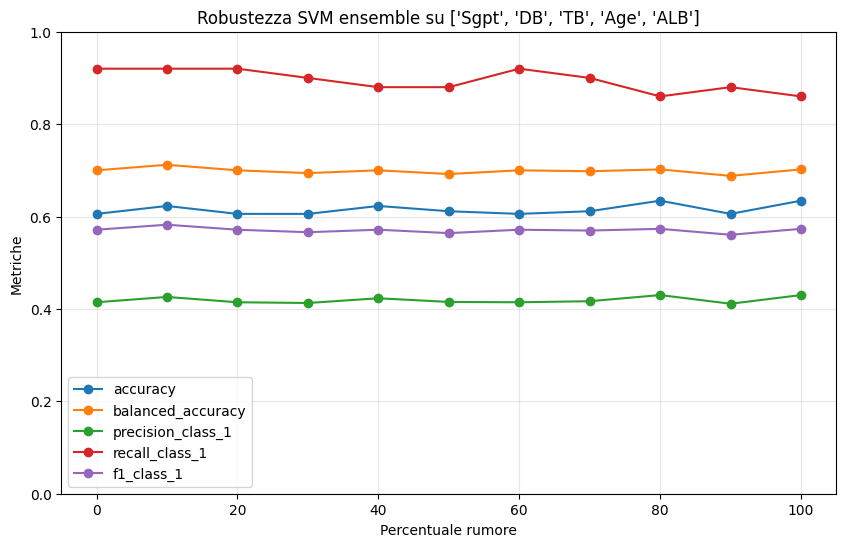

    accuracy  f1_class_1  precision_class_1  recall_class_1  \
0   0.605714    0.571429           0.414414            0.92   
1   0.622857    0.582278           0.425926            0.92   
2   0.605714    0.571429           0.414414            0.92   
3   0.605714    0.566038           0.412844            0.90   
4   0.622857    0.571429           0.423077            0.88   
5   0.611429    0.564103           0.415094            0.88   
6   0.605714    0.571429           0.414414            0.92   
7   0.611429    0.569620           0.416667            0.90   
8   0.634286    0.573333           0.430000            0.86   
9   0.605714    0.560510           0.411215            0.88   
10  0.634286    0.573333           0.430000            0.86   

    balanced_accuracy    colonne_sporcate  frac_rumore  percentuale_rumore  
0               0.700  Sgpt,DB,TB,Age,ALB          0.0                   0  
1               0.712  Sgpt,DB,TB,Age,ALB          0.1                  10  
2           

In [69]:
risultati_rumore_df, risultati_completi_rumore = test_noise_progressivo_SVM(
    df=df_encoded,
    target_col="Selector",
    cols_to_corrupt=migliori,
    noise_level=0.5,
    test_size=0.3,
    random_state=42,
    feature_group="migliori",
    stratify=True,
)